# Decision Tree Classification

## Objective

This notebook implements a Decision Tree classifier for vehicular misbehavior detection using the processed VeReMi dataset.

Decision Trees are capable of learning complex non-linear relationships between features and provide interpretable classification rules.

The performance of the Decision Tree model will be compared with the Logistic Regression baseline developed in the previous notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Loading Processed Dataset

The processed training and testing datasets generated during the preprocessing phase are loaded for model development.

These datasets already contain standardized numerical features and engineered attributes, allowing the notebook to focus exclusively on model training and evaluation.

In [2]:
BASE_PATH = Path("..")

DATA_PATH = BASE_PATH/"data"

PROCESSED_PATH = DATA_PATH/"processed"

MODELS_PATH = BASE_PATH/"models"

OUTPUT_PATH = BASE_PATH/"outputs"

OUTPUT_FIGURES = OUTPUT_PATH/"figures"

OUTPUT_METRICS = OUTPUT_PATH/"metrics"

OUTPUT_REPORTS = OUTPUT_PATH/"reports"

BASELINE_MODEL_PATH = MODELS_PATH/"baseline_models"

In [3]:
train = pd.read_csv(
    PROCESSED_PATH/"train_processed.csv"
)

test = pd.read_csv(
    PROCESSED_PATH/"test_processed.csv"
)

In [4]:
print(train.shape)

print(test.shape)

(80000, 23)
(20000, 23)


In [5]:
X_train = train.drop(columns=["attack"])

y_train = train["attack"]

X_test = test.drop(columns=["attack"])

y_test = test["attack"]

In [6]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(80000, 22)
(20000, 22)
(80000,)
(20000,)


# Decision Tree Model Training

A Decision Tree classifier is trained using the processed training dataset.

Decision Trees recursively partition the feature space into homogeneous regions, enabling the model to capture complex non-linear relationships without requiring feature transformations.

In [7]:
dt = DecisionTreeClassifier(

    random_state=42,

    max_depth=10,

    min_samples_split=20,

    min_samples_leaf=10
)

dt.fit(

    X_train,

    y_train

)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [8]:
joblib.dump(

    dt,

    BASELINE_MODEL_PATH/
    "decision_tree.pkl"

)

['..\\models\\baseline_models\\decision_tree.pkl']

In [9]:
dt

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# 7. Model Prediction

The trained Decision Tree classifier is used to predict both the class labels and class probabilities for the testing dataset.

Class labels are required for computing evaluation metrics, whereas predicted probabilities are used for ROC and Precision-Recall analyses.

In [10]:
y_pred = dt.predict(X_test)

y_prob = dt.predict_proba(X_test)[:,1]

In [11]:
print(y_pred[:10])

print()

print(y_prob[:10])

[0 0 1 1 0 0 0 1 1 0]

[0.47309083 0.38683128 0.51427423 0.5140669  0.4318408  0.46218487
 0.47309083 0.71428571 0.59748428 0.4318408 ]


# 8. Model Evaluation

The Decision Tree classifier is evaluated using several classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

These metrics provide complementary insights into the classifier's performance and enable direct comparison with the Logistic Regression baseline.

In [13]:
metrics = {

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1 Score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_prob)

}

metrics_df = pd.DataFrame(

    metrics.items(),

    columns=["Metric","Value"]

)

metrics_df

,Metric,Value
0,Accuracy,0.544950
1,Precision,0.499399
2,Recall,0.319771
3,F1 Score,0.389891
4,ROC AUC,0.550115


In [14]:
metrics_df.to_csv(

    OUTPUT_METRICS/

    "decision_tree_metrics.csv",

    index=False

)

# 9. Confusion Matrix

The confusion matrix summarizes the classifier's predictions by comparing the predicted class labels with the true labels.

It provides the number of correctly and incorrectly classified samples for each class, enabling detailed analysis of false positives and false negatives.

In [15]:
cm = confusion_matrix(

    y_test,

    y_pred

)

cm

array([[7991, 2915],
       [6186, 2908]])

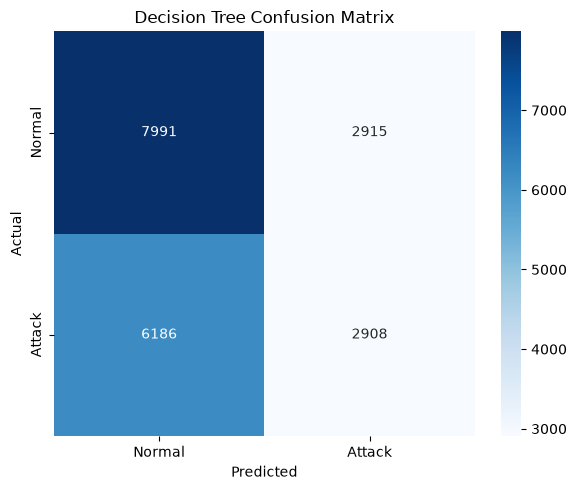

In [16]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Normal","Attack"],

    yticklabels=["Normal","Attack"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()

plt.savefig(

    OUTPUT_FIGURES/

    "decision_tree_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# 10. Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

This detailed evaluation enables comparison of the Decision Tree model with the Logistic Regression baseline developed previously.

In [17]:
report = classification_report(

    y_test,

    y_pred,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.563659,0.732716,0.637165,10906.00000
1,0.499399,0.319771,0.389891,9094.00000
accuracy,0.544950,0.544950,0.544950,0.54495
macro avg,0.531529,0.526244,0.513528,20000.00000
weighted avg,0.534440,0.544950,0.524729,20000.00000


In [18]:
report_df.to_csv(

    OUTPUT_REPORTS/

    "decision_tree_classification_report.csv"

)

## Discussion of Decision Tree Results

The Decision Tree classifier demonstrated a significant improvement over the Logistic Regression baseline, particularly in terms of attack detection capability.

Although the overall accuracy remained similar, the recall increased substantially, indicating that the Decision Tree successfully captured non-linear relationships within the VeReMi dataset.

The confusion matrix shows that the model correctly identified **2,908 attack instances**, compared with only **221** detected by Logistic Regression.

Similarly, the F1-score improved considerably, reflecting a better balance between precision and recall.

Despite these improvements, the model still produced a large number of false negatives and only a modest ROC-AUC score. These observations suggest that a single Decision Tree is capable of learning meaningful attack patterns but remains limited in its generalization ability.

The subsequent experiments with ensemble learning methods, including Random Forest and XGBoost, are expected to provide more robust and accurate attack detection.

# 11. Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve evaluates the classifier's ability to distinguish between normal and malicious vehicular messages across different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the classifier's discriminative capability. A higher ROC-AUC value indicates better separation between the two classes.


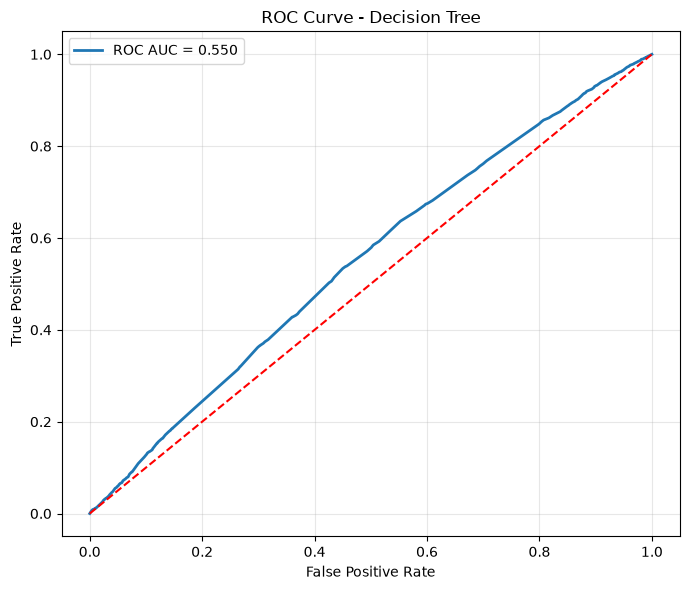

In [19]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC AUC = {metrics['ROC AUC']:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES /
    "decision_tree_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The ROC curve lies only moderately above the random classification line, indicating that the Decision Tree possesses limited discriminative capability under the current hyperparameter settings.

Although the model outperforms the Logistic Regression baseline, further improvements are expected through ensemble learning techniques such as Random Forest and XGBoost.

# 12. Precision-Recall Curve

The Precision-Recall Curve illustrates the trade-off between precision and recall across different decision thresholds.

Since attack detection is the primary objective of this research, the Precision-Recall curve provides valuable insight into the model's capability to correctly identify malicious messages while minimizing false alarms.

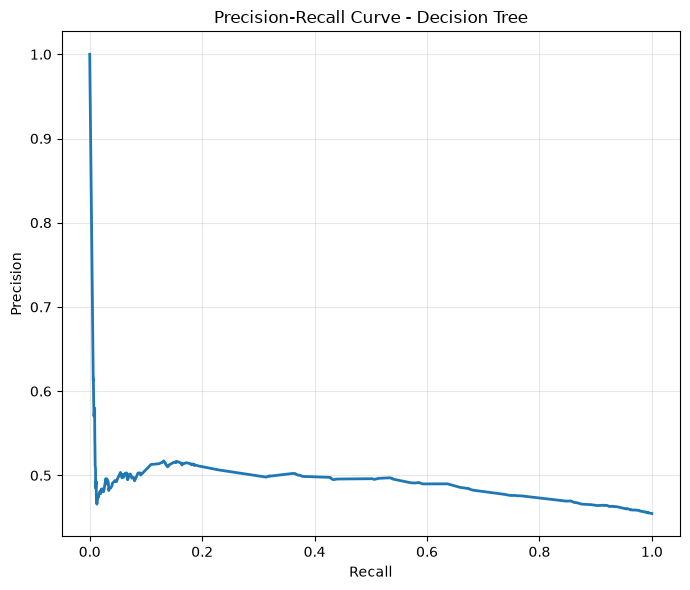

In [20]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Decision Tree")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES /
    "decision_tree_pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Precision-Recall curve demonstrates the trade-off between correctly identifying attack instances and minimizing false positive predictions.

The current Decision Tree achieves a better balance than Logistic Regression, although considerable improvement is still possible through more sophisticated ensemble classifiers.

# 13. Feature Importance Analysis

Decision Trees estimate the importance of each feature based on the reduction in impurity achieved during recursive splitting.

Features with higher importance values contribute more significantly to attack classification.

This analysis provides insight into which vehicular attributes are most influential for distinguishing malicious behavior.

In [21]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": dt.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
1,rcvTime,0.319233
2,pos_0,0.066841
14,hed_0,0.046639
19,speed_magnitude,0.043185
18,pos_magnitude,0.042966
7,spd_1,0.042767
9,spd_noise_1,0.040435
15,hed_1,0.038567
20,acceleration_magnitude,0.037262
10,acl_0,0.035065


## Interpretation of Feature Importance

The Decision Tree assigned the highest importance to the **rcvTime** feature, indicating that temporal characteristics of received vehicular messages are the strongest predictor of malicious behavior in the current model.

Several position-related attributes, including **pos_0**, **pos_1**, and **pos_magnitude**, also received relatively high importance scores. This suggests that spatial inconsistencies introduced by malicious nodes play a crucial role in attack detection.

Vehicle dynamics, represented by **speed**, **heading**, and **acceleration** features, contributed substantially to the classification process. These findings are consistent with the characteristics of attacks such as Random Speed, Constant Speed, Eventual Stop, and Direction Manipulation, which directly modify vehicular motion parameters.

Conversely, the **type** feature exhibited negligible importance, indicating that message category alone provides limited discriminatory information compared to behavioral measurements.

Overall, the feature importance analysis demonstrates that the Decision Tree primarily relies on temporal, positional, and kinematic attributes when distinguishing normal and malicious vehicular messages.

In [22]:
importance.to_csv(

    OUTPUT_METRICS /
    "decision_tree_feature_importance.csv",

    index=False

)

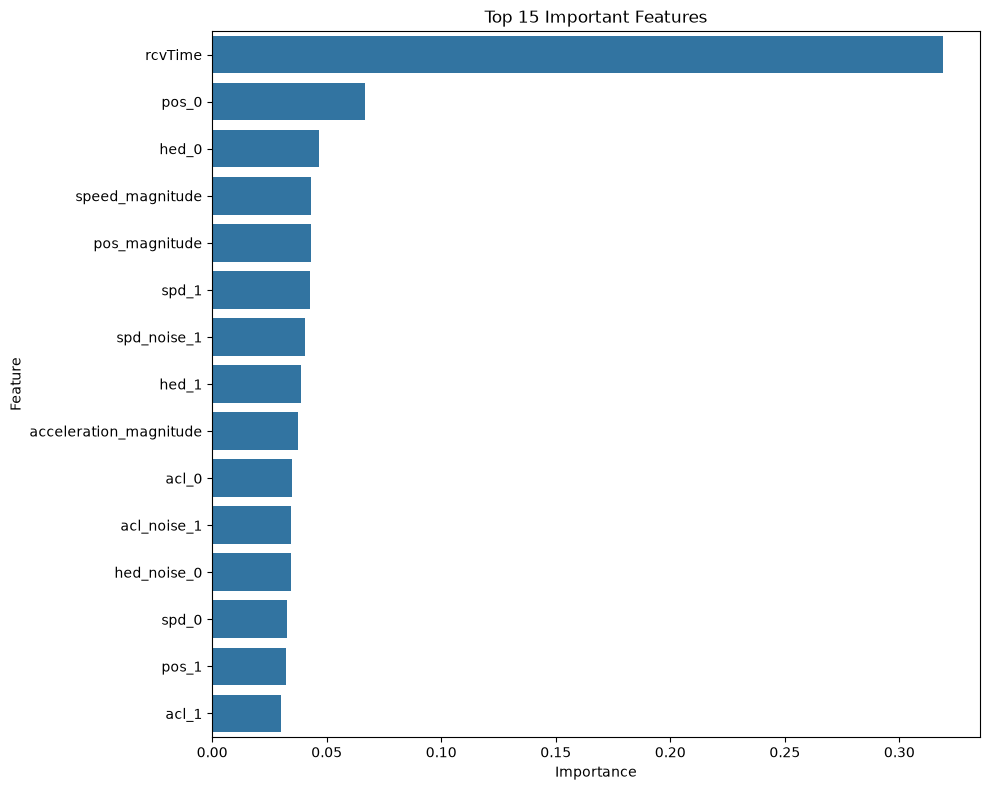

In [23]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig(

    OUTPUT_FIGURES /
    "decision_tree_feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Discussion

The Decision Tree primarily relies on a subset of vehicular motion and positional attributes for attack detection.

The ranking indicates that only a limited number of variables dominate the decision-making process, suggesting that the classifier is capable of identifying informative features while ignoring less relevant variables.

A detailed comparison with Random Forest and XGBoost feature importance rankings will be performed in subsequent experiments.

# 14. Decision Tree Visualization

Decision Trees are inherently interpretable because their classification process can be represented as a hierarchical tree structure.

The visualization below illustrates the learned decision rules, feature splits, and class distributions within the upper levels of the trained Decision Tree.

For readability, only the first few levels of the tree are displayed.

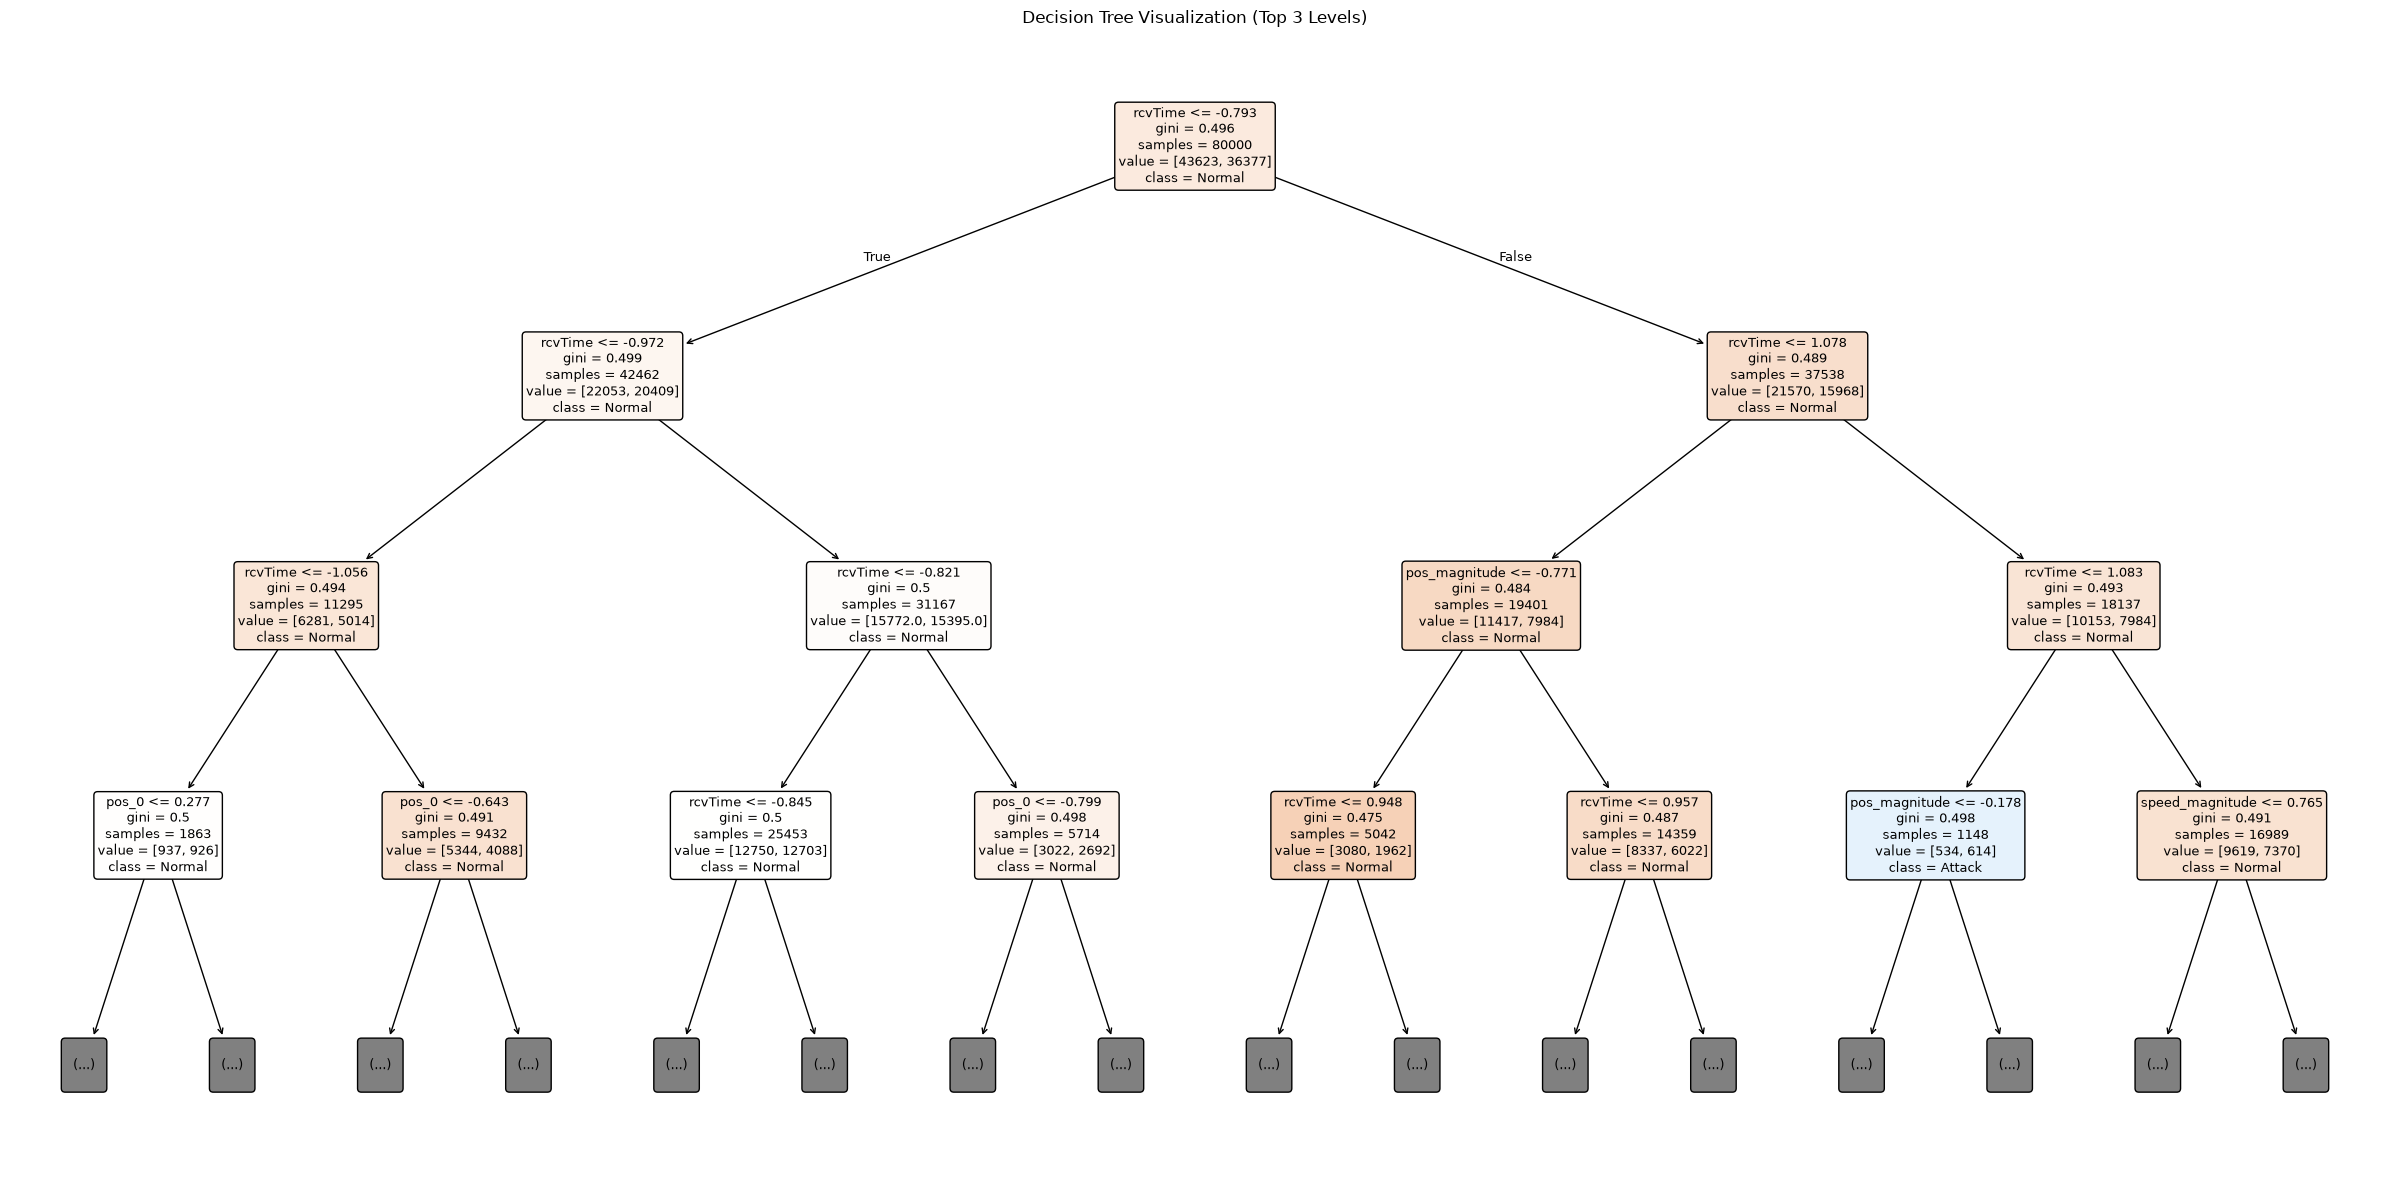

In [24]:
plt.figure(figsize=(24,12))

plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["Normal", "Attack"],
    filled=True,
    rounded=True,
    max_depth=3,      # Show only top 3 levels for readability
    fontsize=9
)

plt.title("Decision Tree Visualization (Top 3 Levels)")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "decision_tree_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of the Decision Tree

The visualization illustrates the hierarchical decision-making process learned by the Decision Tree classifier.

The root node selects **rcvTime** as the first splitting feature, confirming that temporal information provides the greatest reduction in class impurity. Several subsequent nodes continue splitting on the same attribute, indicating that message timing plays a dominant role in distinguishing normal and malicious vehicular communications.

After the initial temporal partitioning, the tree introduces positional attributes such as **pos_0** and **pos_magnitude**, followed by motion-related features including **speed_magnitude**. This progression suggests that the classifier first separates observations based on temporal behavior before refining decisions using spatial and kinematic information.

For visualization purposes, only the first three levels of the tree are presented. The complete model contains additional levels that capture more detailed decision boundaries while maintaining the configured maximum depth of ten.

# 15. Model Summary

The Decision Tree classifier was trained using engineered vehicular features derived from the VeReMi dataset.

The model serves as an interpretable baseline that demonstrates how temporal, positional, and motion-related attributes contribute to attack detection. Although its predictive performance remains moderate, the Decision Tree provides valuable insight into feature importance and decision rules that will be compared against ensemble learning methods in subsequent experiments.

In [25]:
summary = pd.DataFrame({

    "Metric":[
        "Algorithm",
        "Training Samples",
        "Testing Samples",
        "Features",
        "Tree Depth",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        "Decision Tree",
        len(X_train),
        len(X_test),
        X_train.shape[1],
        dt.get_depth(),
        metrics["Accuracy"],
        metrics["Precision"],
        metrics["Recall"],
        metrics["F1 Score"],
        metrics["ROC AUC"]
    ]

})

summary

,Metric,Value
0,Algorithm,Decision Tree
1,Training Samples,80000
2,Testing Samples,20000
3,Features,22
4,Tree Depth,10
5,Accuracy,0.54495
6,Precision,0.499399
7,Recall,0.319771
8,F1 Score,0.389891
9,ROC AUC,0.550115


In [26]:
summary.to_csv(

    OUTPUT_METRICS /
    "decision_tree_summary.csv",

    index=False

)

# 16. Conclusion

A Decision Tree classifier was successfully developed for binary vehicular misbehavior detection using the VeReMi dataset.

Compared with the Logistic Regression baseline, the Decision Tree achieved a substantial improvement in attack recall and F1-score by learning nonlinear relationships among temporal, positional, and motion-related features. Feature importance analysis identified **rcvTime** as the most influential predictor, followed by position, speed, heading, and acceleration attributes.

Despite these improvements, the overall predictive performance remains moderate, indicating that a single Decision Tree has limited generalization capability for this challenging classification task. Ensemble learning algorithms, including Random Forest and XGBoost, are expected to provide stronger predictive performance and improved robustness.

The insights obtained from this interpretable baseline establish a strong foundation for the subsequent ensemble modeling phase of the research.

In [27]:
print("="*60)
print("Decision Tree Notebook Completed Successfully")
print("="*60)

print()

print("Artifacts Generated")

print("- Decision Tree Model")
print("- Evaluation Metrics")
print("- Confusion Matrix")
print("- Classification Report")
print("- ROC Curve")
print("- Precision Recall Curve")
print("- Feature Importance")
print("- Decision Tree Visualization")
print("- Model Summary")

print()

print("Notebook Status : COMPLETE")

Decision Tree Notebook Completed Successfully

Artifacts Generated
- Decision Tree Model
- Evaluation Metrics
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision Recall Curve
- Feature Importance
- Decision Tree Visualization
- Model Summary

Notebook Status : COMPLETE
